<a href="https://colab.research.google.com/github/A-Scode/image-caption-generator/blob/main/face_recognition_using_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import fetch_lfw_people

In [ ]:
lfw = fetch_lfw_people(min_faces_per_person=30)
lfw

{'data': array([[0.39738563, 0.37908497, 0.3503268 , ..., 0.13071896, 0.09803922,
         0.02875817],
        [0.01437909, 0.02745098, 0.05490196, ..., 0.2       , 0.20392157,
         0.21176471],
        [0.14248367, 0.20130719, 0.23267974, ..., 0.6248366 , 0.6235294 ,
         0.6248366 ],
        ...,
        [0.36993465, 0.34771243, 0.31764707, ..., 0.49803922, 0.4130719 ,
         0.36601308],
        [0.06143791, 0.04836601, 0.10849673, ..., 0.26143792, 0.24313726,
         0.23660131],
        [0.36732027, 0.34248367, 0.35555556, ..., 0.96732026, 0.9633987 ,
         0.6745098 ]], dtype=float32),
 'images': array([[[0.39738563, 0.37908497, 0.3503268 , ..., 0.24836601,
          0.18039216, 0.26666668],
         [0.34248367, 0.37777779, 0.36993465, ..., 0.28496733,
          0.18692811, 0.21437909],
         [0.33594772, 0.36078432, 0.35555556, ..., 0.3620915 ,
          0.29281047, 0.27058825],
         ...,
         [0.34771243, 0.36993465, 0.36078432, ..., 0.1124183 ,
     

In [ ]:
y=lfw['target']
x=lfw['images']
x,y

(array([[[0.39738563, 0.37908497, 0.3503268 , ..., 0.24836601,
          0.18039216, 0.26666668],
         [0.34248367, 0.37777779, 0.36993465, ..., 0.28496733,
          0.18692811, 0.21437909],
         [0.33594772, 0.36078432, 0.35555556, ..., 0.3620915 ,
          0.29281047, 0.27058825],
         ...,
         [0.34771243, 0.36993465, 0.36078432, ..., 0.1124183 ,
          0.10718954, 0.0496732 ],
         [0.275817  , 0.33333334, 0.35555556, ..., 0.13071896,
          0.10980392, 0.03529412],
         [0.19607843, 0.23660131, 0.31895426, ..., 0.13071896,
          0.09803922, 0.02875817]],
 
        [[0.01437909, 0.02745098, 0.05490196, ..., 0.16470589,
          0.15816994, 0.14640523],
         [0.02614379, 0.04183007, 0.04052288, ..., 0.18431373,
          0.16470589, 0.15294118],
         [0.03529412, 0.08235294, 0.08627451, ..., 0.18954249,
          0.15816994, 0.13725491],
         ...,
         [0.16993465, 0.18300654, 0.19346406, ..., 0.18692811,
          0.19084968, 0.

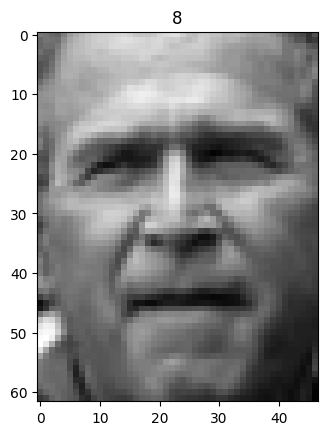

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(x[0] , cmap="gray")
plt.title(y[0])
plt.show()

In [ ]:
x[0].shape , print(y[0])

8


((62, 47), None)

In [ ]:
x.shape , y.shape

((2370, 62, 47), (2370,))

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import torch
from torch.utils.data import Dataset

class FaceDataset(Dataset):
  def __init__(self , images , labels):
    self.images= torch.tensor(images).unsqueeze(1).float() / 255.0
    self.labels = torch.tensor(labels)

  def __len__(self):
    return (len(self.images))

  def __getitem__(self, index):
    return self.images[index] , self.labels[index]




In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class FaceCNN(nn.Module):

  def __init__(self, num_classess) -> None:
    super().__init__()

    self.conv1 = nn.Conv2d(in_channels=1,out_channels=32, kernel_size=3)
    self.bn1 = nn.BatchNorm2d(32)
    self.conv2 = nn.Conv2d(32,64,3)
    self.bn2 = nn.BatchNorm2d(64)
    self.conv3 = nn.Conv2d(64,256,3)
    self.bn3 = nn.BatchNorm2d(256)
    self.conv4 = nn.Conv2d(256,128,3)
    self.bn4 = nn.BatchNorm2d(128)

    self.pool = nn.MaxPool2d(2,2)
    self.dropout = nn.Dropout(p=0.1)

    self.fc1 = nn.Linear(256, 2408)
    self.fc2 = nn.Linear(2408, 1024)
    self.fc3 = nn.Linear(1024, 512)
    self.fc4 = nn.Linear(512, 256)
    self.embedding = nn.Linear(256 , 128)
    self.classifier = nn.Linear(128 , num_classess)


  def forward(self, x ):
    x = self.pool(F.relu(self.bn1(self.conv1(x))))
    x = self.pool(F.relu(self.bn2(self.conv2(x))))
    x = self.pool(F.relu(self.bn3(self.conv3(x))))
    x = self.pool(F.relu(self.bn4(self.conv4(x))))
    x = torch.flatten(x,1)


    # this layer will not be registered in model.parameters therefore no weight update
    # if self.fc1 is None:
    #   self.fc1 = nn.Linear(x.shape[1] , 256).to(x.device)

    x  = F.relu(self.fc1(x))
    x  = F.relu(self.fc2(x))
    x  = F.relu(self.fc3(x))
    x  = F.relu(self.fc4(x))

    emb = self.embedding(x)

    out  = self.classifier(emb)

    return out , emb

In [ ]:
from sklearn.model_selection import train_test_split

x_train ,x_test , y_train, y_test = train_test_split( x , y  , test_size=0.2 , random_state=42)

x_train.shape ,x_test.shape , y_train.shape, y_test.shape

((1896, 62, 47), (474, 62, 47), (1896,), (474,))

In [ ]:
train_dataset =FaceDataset(x_train , y_train)
test_dataset = FaceDataset(x_test , y_test)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset , batch_size=32 , shuffle=True , num_workers=4)
test_loader = DataLoader(test_dataset , batch_size=32  , shuffle=True , num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
num_classess = len(lfw.target_names)
model =  FaceCNN(num_classess).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(model.parameters() , lr=0.0005)

for epoch in  range(30):
  for images , labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    model.train()
    optimizer.zero_grad()

    out ,emb = model(images)

    loss  = criterion(out , labels)
    print(f"Epoch {epoch} : loss {loss}")
    loss.backward()
    optimizer.step()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 0 : loss 3.5162744522094727
Epoch 0 : loss 3.511798620223999
Epoch 0 : loss 3.4635515213012695
Epoch 0 : loss 3.413620948791504
Epoch 0 : loss 3.408424139022827
Epoch 0 : loss 3.2621521949768066
Epoch 0 : loss 3.2173149585723877
Epoch 0 : loss 3.0410733222961426
Epoch 0 : loss 3.461446762084961
Epoch 0 : loss 3.194662570953369
Epoch 0 : loss 3.198795795440674
Epoch 0 : loss 3.2578842639923096
Epoch 0 : loss 3.1952133178710938
Epoch 0 : loss 3.09254789352417
Epoch 0 : loss 3.1627092361450195
Epoch 0 : loss 3.4271442890167236
Epoch 0 : loss 3.3404788970947266
Epoch 0 : loss 2.9944121837615967
Epoch 0 : loss 2.9669713973999023
Epoch 0 : loss 3.07973313331604
Epoch 0 : loss 3.157799482345581
Epoch 0 : loss 2.9477665424346924
Epoch 0 : loss 2.963650941848755
Epoch 0 : loss 3.6825525760650635
Epoch 0 : loss 2.9650442600250244
Epoch 0 : loss 3.0293526649475098
Epoch 0 : loss 2.9993205070495605
Epoch 0 : loss 3.2158305644989014
Epoch 0 : loss 2.8008930683135986
Epoch 0 : loss 2.992761135

In [ ]:
model.eval()

FaceCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc1): Linear(in_features=256, out_features=2408, bias=True)
  (fc2): Linear(in_features=2408, out_features=1024, bias=True)
  (fc3): Linear(in_features=1024, out_features=512, bias=True)
  (fc4): Linear(in_features=512, out_features=256, bias=True)
  (embe

In [ ]:
correct = 0
total  = 0

with torch.no_grad():

  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    out , _ = model(images)
    _ , pred = torch.max(out , 1)
    total +=  labels.size(0)
    correct += (pred == labels).sum().item()
  acc = 100*correct/total

  print("test Accuracy : " , acc)



test Accuracy :  77.42616033755274


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import cv2
import numpy as np
from base64 import b64decode


def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
  ''')

  display(js)
  data = eval_js('takePhoto({})'.format(quality))

  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)

  return filename

In [ ]:

photo1 = take_photo("photo1.jpg")
print("Saved to", photo1)

photo2 = take_photo("photo2.jpg")

<IPython.core.display.Javascript object>

Saved to photo1.jpg


<IPython.core.display.Javascript object>

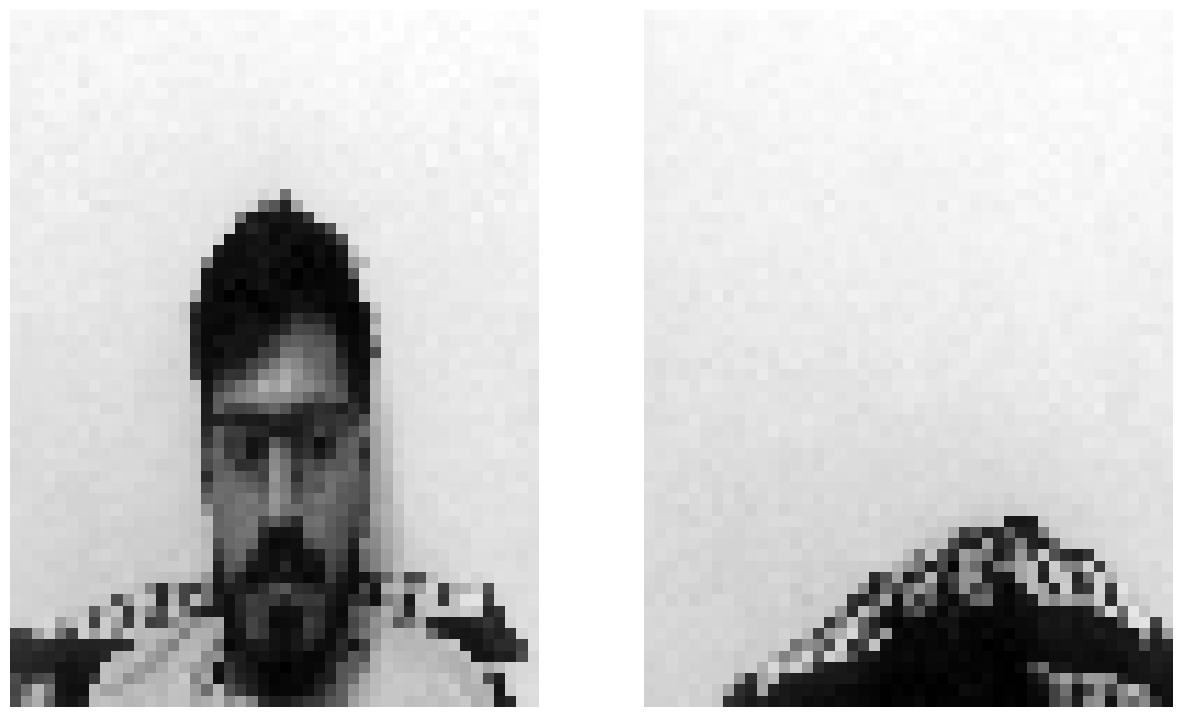

In [ ]:
im1 = cv2.imread(photo1)
im2 = cv2.imread(photo2)

im1 = cv2.cvtColor(im1, cv2.COLOR_BGR2GRAY)
im2 = cv2.cvtColor(im2, cv2.COLOR_BGR2GRAY)

# resizing
im1 = cv2.resize(im1 , (47,62))
im2 = cv2.resize(im2 , (47,62))

plt.figure(figsize=(15,15))

ax1 = plt.subplot(121)
ax1.axis("off")
ax1.imshow(im1 , cmap="gray")

ax2 = plt.subplot(122)
ax2.axis("off")
ax2.imshow(im2 , cmap="gray")

plt.show()

# plt.imshow(im1 , cmap="gray")
# plt.title("photo 1")
# plt.axis('off')


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Shape is (62, 47, 3) -> (H, W, C)
t1 = torch.from_numpy(im1).float() / 255
t2 = torch.from_numpy(im2).float() / 255

t1 = t1.unsqueeze(0).unsqueeze(0).to(device)
t2 = t2.unsqueeze(0).unsqueeze(0).to(device)

print(t1.shape)

model.eval()

_ ,emb_1 = model(t1)
_ ,emb_2 = model(t2)


print("emb1 : " , emb_1)
print("emb2 : " , emb_2)

emb_1 = emb_1.reshape(1,-1)
emb_2 = emb_2.reshape(1,-1)

cs = cosine_similarity(emb_1.to("cpu").detach().numpy() , emb_2.to("cpu").detach().numpy())


print("cosine similarity :" , cs[0][0])

torch.Size([1, 1, 62, 47])
emb1 :  tensor([[ 109.2676,  105.0958,  263.6151,   71.4132,   99.8907,   35.9186,
          -54.7117,  142.2284,  -15.5846,  -74.3627, -139.4381,  136.1427,
          109.9211,   -0.6255,  -54.5391,   10.5028, -138.8171,  -10.9565,
          -72.2909,  100.5127,  -10.0386, -278.5854,  225.7936,  105.0089,
          138.7366,  -33.8452,  156.7229,  -98.4801,   18.7251,  -75.5092,
         -178.2318,   33.9345, -272.1185, -176.0743,  -46.0212,  112.3300,
            8.3785,  208.7847,  -94.8084,  330.0351,  131.3966,   36.6557,
          -43.4136,  179.6454,   22.5421, -152.4850,  -97.3860, -258.5486,
         -230.6244,  180.7749,   -8.2983,  -92.1530,   33.5967,   -9.1924,
         -113.5189,    7.8877,   52.8970,  -17.7829, -191.2304,  -35.7642,
         -189.6361,  126.8910,  -22.5528,  -28.6616,  -68.2153,   27.2417,
          -21.2882,  156.5044,  -44.0711,  -41.9746,   47.6319,  -33.2446,
         -126.1443,  216.2527,   68.7378,   19.7309,  -43.0536,  